# [Voting Ensemble](https://youtu.be/_W1i-c_6rOk?list=PLKnIA16_Rmvbr7zKYQuBfsVkjoLcJgxHH)  

## Assumptions:  
* Base models should be different.
* All base models minimum accuracy should be 51%.


#### How is it improving probability?  
![ytss](assets/1_voting.png)  
**Explanation of the example:**  
In this example, three independent models `m1`, `m2`, and `m3` each have 70% accuracy and 30% error. The tree diagram enumerates all possible combinations of their predictions by multiplying probabilities along each path. Outcomes where at least two models are correct (three-correct with probability `0.7^3 = 34.3%`, and two-correct-one-wrong with probability `3 × 0.7^2 × 0.3 = 44.1%`) together account for 78.4% of all cases, which is higher than the accuracy of any single model. This increase occurs because incorrect predictions made by one model are often overridden by the other two. However, in an unweighted voting ensemble, if any model had accuracy below 50%, its incorrect votes would occur more frequently than correct ones, increasing the probability of wrong majority paths and thereby reducing the overall ensemble accuracy.


---



# [Classification Voting Ensemble](https://www.youtube.com/watch?v=pGQnNYdPTvY&list=PLKnIA16_Rmvbr7zKYQuBfsVkjoLcJgxHH&index=86&pp=iAQB0gcJCU0KAYcqIYzv)  

While understaing intuition above i kinda understood this one down in the example... with voting as 'soft'

### Soft vs Hard Voting. 
in soft voting.. models give the percentage, for example if its a binary classification problem between A and B. model could return 0.7 for A and 0.3 for B. its called soft voting. where not just the result is returned but the confidence is returned as well.  
in hard voting confidence isn't returned... just straight up either A or B.  

---

### Weights.  
Weights can be assigned to models based on their performance... if a model is performing well... have that model more weighted will result in better accuracy. it could be added so soft voting so that if a model is returning the prediction with utmost confidence like lets say its saying 0.9 for class A and 0.1 for B, and its right most of the time... giving it more weight will definitely be beneficial... because now its resultant value will be preferred.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [22]:
iris = load_iris()
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df['label'] = iris.target
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
54,6.5,2.8,4.6,1.5,1
111,6.4,2.7,5.3,1.9,2
108,6.7,2.5,5.8,1.8,2
20,5.4,3.4,1.7,0.2,0
72,6.3,2.5,4.9,1.5,1


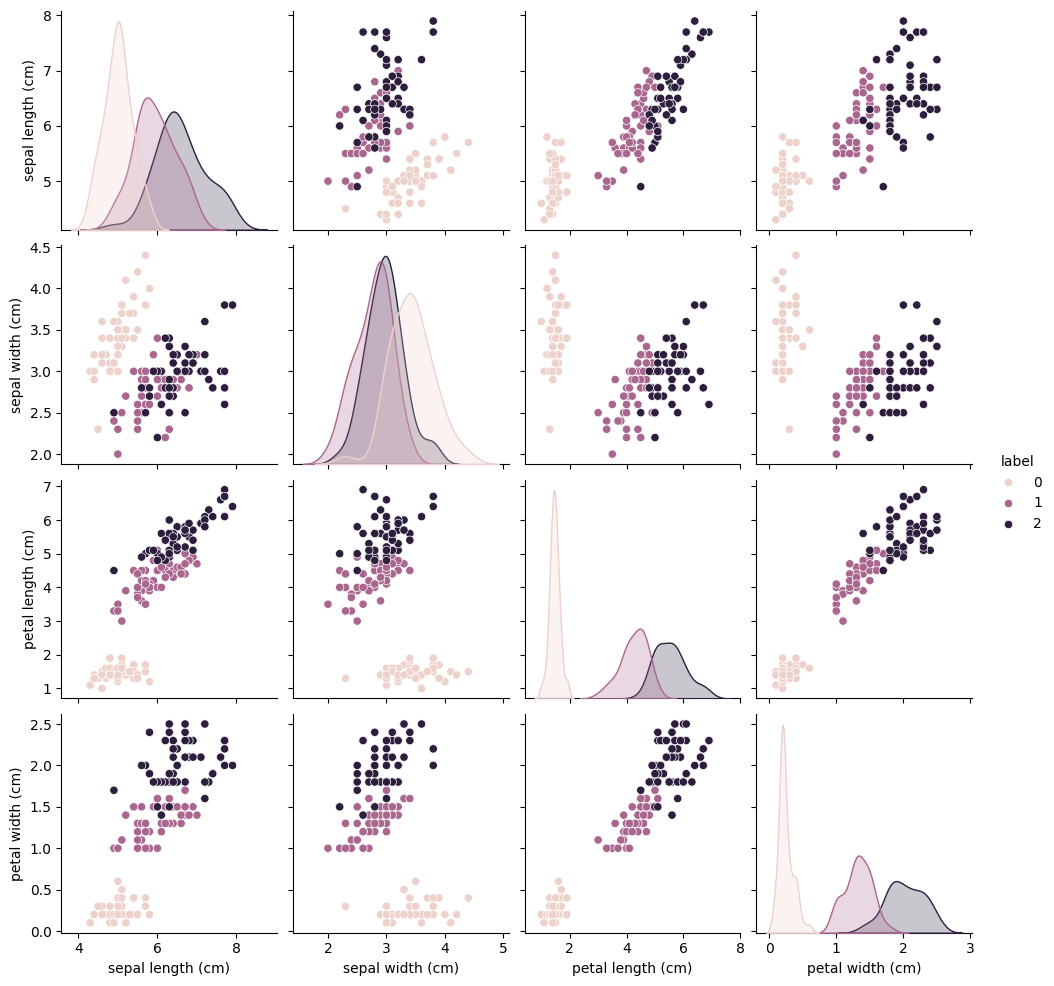

In [23]:
 import seaborn as sns

sns.pairplot(df,hue='label')

In [28]:
new_df = df[df['label']!=0][['sepal length (cm)','sepal width (cm)','label']] # taking only these two because classification in these two is most complex also got rid 0 in lables cuz that was separate in plot.. don't want easyness

new_df.head()

,sepal length (cm),sepal width (cm),label
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

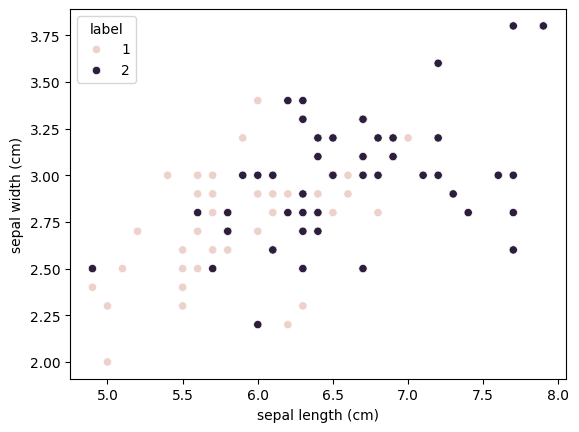

In [27]:
sns.scatterplot(new_df,x='sepal length (cm)',y='sepal width (cm)',hue='label

In [31]:
X = new_df.iloc[:,0:2]
y = new_df.iloc[:,-1]

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [34]:
lr = LogisticRegression()
kn = KNeighborsClassifier()
rf = RandomForestClassifier()

In [35]:
estimators = [('lr',lr),('kn',kn),('rf',rf)]

In [36]:
for est in estimators:
    x = cross_val_score(est[1],X,y,cv=10,scoring='accuracy')
    print(est[0],np.round(np.mean(x),2))

lr 0.75
kn 0.62
rf 0.59


In [37]:
from sklearn.ensemble import VotingClassifier



## Hard voting

In [38]:
vc = VotingClassifier(estimators=estimators)
x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.67


In [39]:
## Soft Voting
vc = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.65


## Weights

In [42]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators,weights=[i,j,k])
            x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
            print(f"for i = {i}, j = {j}, k = {k}",np.round(np.mean(x),2))

for i = 1, j = 1, k = 1 0.65
for i = 1, j = 1, k = 2 0.65
for i = 1, j = 1, k = 3 0.61
for i = 1, j = 2, k = 1 0.63
for i = 1, j = 2, k = 2 0.67
for i = 1, j = 2, k = 3 0.68
for i = 1, j = 3, k = 1 0.62
for i = 1, j = 3, k = 2 0.64
for i = 1, j = 3, k = 3 0.67
for i = 2, j = 1, k = 1 0.71
for i = 2, j = 1, k = 2 0.67
for i = 2, j = 1, k = 3 0.66
for i = 2, j = 2, k = 1 0.68
for i = 2, j = 2, k = 2 0.67
for i = 2, j = 2, k = 3 0.66
for i = 2, j = 3, k = 1 0.62
for i = 2, j = 3, k = 2 0.67
for i = 2, j = 3, k = 3 0.67
for i = 3, j = 1, k = 1 0.75
for i = 3, j = 1, k = 2 0.72
for i = 3, j = 1, k = 3 0.68
for i = 3, j = 2, k = 1 0.72
for i = 3, j = 2, k = 2 0.68
for i = 3, j = 2, k = 3 0.66
for i = 3, j = 3, k = 1 0.68
for i = 3, j = 3, k = 2 0.68
for i = 3, j = 3, k = 3 0.66


## Classifiers of same algo


In [43]:
from sklearn.svm import SVC

In [44]:
from sklearn.datasets import make_classification

X,y = make_classification(n_samples=1000,n_features=20,n_informative=15,n_redundant=5,random_state=2)

svc1 = SVC(probability=True,kernel='poly',degree = 1)
svc2 = SVC(probability=True,kernel='poly',degree = 2)
svc3 = SVC(probability=True,kernel='poly',degree = 3)
svc4 = SVC(probability=True,kernel='poly',degree = 4)
svc5 = SVC(probability=True,kernel='poly',degree = 5)

estimators = [('svc1',svc1),('svc2',svc2),('svc3',svc3),('svc4',svc4),('svc5',svc5)]

for est in estimators:
    x = cross_val_score(est[1],X,y,cv=10,scoring='accuracy')
    print(est[0],np.round(np.mean(x),2))

svc1 0.85
svc2 0.85
svc3 0.89
svc4 0.81
svc5 0.86


In [47]:
vc1 = VotingClassifier(estimators=estimators,voting='soft')

x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

#got the high accuracy from all of them...

0.93


# [Regression Voting Ensemble](https://youtu.be/ut4vh59rGkw?list=PLKnIA16_Rmvbr7zKYQuBfsVkjoLcJgxHH)



Simple stuff, takes the ouput of all the models... calculates their mean and returns that number as final prediction.  


## Code

In [50]:
from sklearn.datasets import fetch_california_housing
import numpy as np

In [101]:
X,y = fetch_california_housing(return_X_y=True)
X = X[0:3000,:]
y = y[0:3000]

# reducing the size of dataset because my laptop is sloppy.

In [102]:
X.shape

(3000, 8)

In [103]:
y

array([4.526, 3.585, 3.521, ..., 1.002, 0.826, 0.882], shape=(3000,))

In [104]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

In [105]:
estimator = [('lr',LinearRegression()),('dt',DecisionTreeRegressor()),('svr',SVR())]  

for est in estimator:
    x = cross_val_score(est[1],X,y,cv=10,scoring='r2')
    print(est[0],np.round(np.mean(x),2))

# ofc dataset isn't ideal, i just have to use all of the models on it for observation purposes. and models can be tuned for better performance but thats not the purpose right now either.

lr -0.28
dt 0.05
svr -1.69


In [106]:
from sklearn.ensemble import VotingRegressor

vr = VotingRegressor(estimators=estimator)

x = cross_val_score(vr,X,y,cv=10,scoring='r2')
print(np.round(np.mean(x),2))

0.11


In [110]:
# weights 1 to 3

for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vr = VotingRegressor(estimators=estimator,weights=[i,j,k])
            x = cross_val_score(vr,X,y,cv=10,scoring='r2')
            print(f"for i = {i},j = {j}, k = {k} ---->",np.round(np.mean(x),2))

for i = 1,j = 1, k = 1 ----> 0.1
for i = 1,j = 1, k = 2 ----> -0.15
for i = 1,j = 1, k = 3 ----> -0.37
for i = 1,j = 2, k = 1 ----> 0.22
for i = 1,j = 2, k = 2 ----> 0.06
for i = 1,j = 2, k = 3 ----> -0.11
for i = 1,j = 3, k = 1 ----> 0.23
for i = 1,j = 3, k = 2 ----> 0.17
for i = 1,j = 3, k = 3 ----> 0.03
for i = 2,j = 1, k = 1 ----> 0.11
for i = 2,j = 1, k = 2 ----> -0.05
for i = 2,j = 1, k = 3 ----> -0.21
for i = 2,j = 2, k = 1 ----> 0.2
for i = 2,j = 2, k = 2 ----> 0.1
for i = 2,j = 2, k = 3 ----> -0.02
for i = 2,j = 3, k = 1 ----> 0.26
for i = 2,j = 3, k = 2 ----> 0.18
for i = 2,j = 3, k = 3 ----> 0.08
for i = 3,j = 1, k = 1 ----> 0.07
for i = 3,j = 1, k = 2 ----> -0.01
for i = 3,j = 1, k = 3 ----> -0.13
for i = 3,j = 2, k = 1 ----> 0.18
for i = 3,j = 2, k = 2 ----> 0.11
for i = 3,j = 2, k = 3 ----> 0.02
for i = 3,j = 3, k = 1 ----> 0.23
for i = 3,j = 3, k = 2 ----> 0.19
for i = 3,j = 3, k = 3 ----> 0.11


In [117]:
# using the same algorithm with different hyperparametrs.  
estimator = [('dt1',DecisionTreeRegressor(max_depth=2)),('dt2',DecisionTreeRegressor(max_depth=3)),
              ('dt3',DecisionTreeRegressor(max_depth=5)),('dt4',DecisionTreeRegressor(max_depth=7)),('dt5',DecisionTreeRegressor(max_depth=9))]

for est in estimator:
    x = cross_val_score(est[1],X,y,cv=10,scoring='r2')
    print(est[0],np.round(np.mean(x),2))

dt1 -0.72
dt2 -0.28
dt3 0.17
dt4 0.2
dt5 0.18


In [118]:
vr = VotingRegressor(estimators=estimator)
x = cross_val_score(vr,X,y,cv=10,scoring='r2')
print(np.round(np.mean(x),2))

0.17


In [121]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            for l in range (1,4):
                for k in range(1,4):
                    for m in range(1,4):
                        vr = VotingRegressor(estimators=estimator,weights=[i,j,k,l,m])
                        x = cross_val_score(vr,X,y,cv=10,scoring='r2')
                        print(f"for i = {i},j = {j}, k = {k},l = {l}, m = {m} ---->",np.round(np.mean(x),2))

for i = 1,j = 1, k = 1,l = 1, m = 1 ----> 0.19
for i = 1,j = 1, k = 1,l = 1, m = 2 ----> 0.21
for i = 1,j = 1, k = 1,l = 1, m = 3 ----> 0.23
for i = 1,j = 1, k = 2,l = 1, m = 1 ----> 0.19
for i = 1,j = 1, k = 2,l = 1, m = 2 ----> 0.23
for i = 1,j = 1, k = 2,l = 1, m = 3 ----> 0.25
for i = 1,j = 1, k = 3,l = 1, m = 1 ----> 0.2
for i = 1,j = 1, k = 3,l = 1, m = 2 ----> 0.23
for i = 1,j = 1, k = 3,l = 1, m = 3 ----> 0.25
for i = 1,j = 1, k = 1,l = 2, m = 1 ----> 0.19
for i = 1,j = 1, k = 1,l = 2, m = 2 ----> 0.25
for i = 1,j = 1, k = 1,l = 2, m = 3 ----> 0.28
for i = 1,j = 1, k = 2,l = 2, m = 1 ----> 0.23
for i = 1,j = 1, k = 2,l = 2, m = 2 ----> 0.26
for i = 1,j = 1, k = 2,l = 2, m = 3 ----> 0.27
for i = 1,j = 1, k = 3,l = 2, m = 1 ----> 0.21
for i = 1,j = 1, k = 3,l = 2, m = 2 ----> 0.25
for i = 1,j = 1, k = 3,l = 2, m = 3 ----> 0.28
for i = 1,j = 1, k = 1,l = 3, m = 1 ----> 0.22
for i = 1,j = 1, k = 1,l = 3, m = 2 ----> 0.26
for i = 1,j = 1, k = 1,l = 3, m = 3 ----> 0.25
for i = 1,j = 